## Project : Exploing What Makes Movies Successful by Analyzing both Box Office and Rotten Tomatoes Review 

### Bussiness understanding
Our company has decided to launch a new movie studio to join the ranks of companies creating original video content. However, we currently lack knowledge about what types of movies are profitable. The goal of this project is to use real-world data to analyze which kinds of films perform best at the box office, then translate those findings into clear, actionable business insights.

The goal is to help our new movie studio make informed decisions by analyzing which types of films do best in terms of both critical reception and box office revenue.
## Goal of the analysis   
 I explored what types of films are performing best  both at the box office and with critics.
This project compares financial performance (from Box Office Mojo) and critic reviews (from Rotten Tomatoes) to uncover trends, success factors, and actionable insights
 
    


# Movie Analysis for The New Studio Launch 
## Dataset: Box Office (bom.movie_gross.csv)
The dataset contains :
- Movie title
- Production studio
- Domestic, foreign, and total gross revenue
- Year of release


In [110]:
#Import important libraries 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [111]:

# Display settings
pd.set_option('display.float_format', lambda x: f'{x:,.0f}')
# Load box office data
box_office = pd.read_csv("C:/Users/PC/Documents/moringa/Phase2/Assessment/phase2project_analysis/data/cleaned_bom.movie_gross.csv")
# Quick look
box_office.head()


,title,studio,domestic_gross,foreign_gross,year,total_gross
0,Toy Story 3,BV,"415,000,000","652,000,000",2010,"1,067,000,000"
1,Alice in Wonderland (2010),BV,"334,200,000","691,300,000",2010,"1,025,500,000"
2,Harry Potter and the Deathly Hallows Part 1,WB,"296,000,000","664,300,000",2010,"960,300,000"
3,Inception,WB,"292,600,000","535,700,000",2010,"828,300,000"
4,Shrek Forever After,P/DW,"238,700,000","513,900,000",2010,"752,600,000"


## Data Cleaning
Check for any missing values 

In [113]:
box_office.isnull().sum()

title             0
studio            0
domestic_gross    0
foreign_gross     0
year              0
total_gross       0
dtype: int64

## Check on the Performance Over Time for Box Office

Let’s see how total gross earnings have changed over the years.


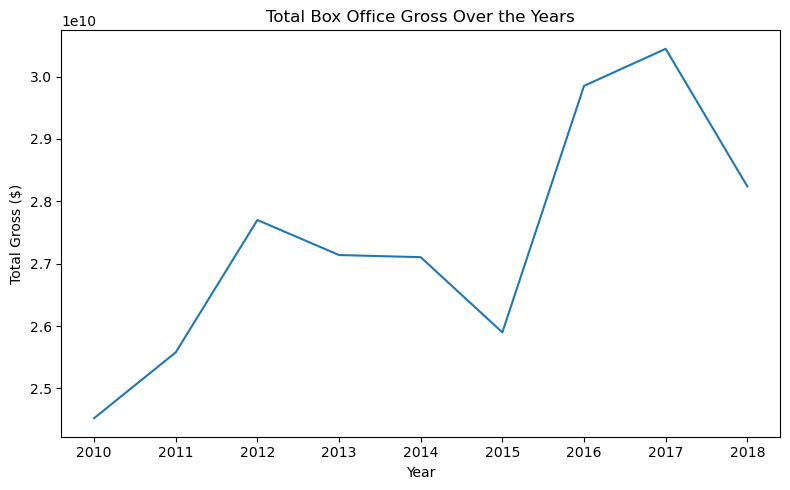

In [275]:
# Group by year
gross_by_year = box_office.groupby('year')['total_gross'].sum().reset_index()
#Graph Plot
plt.figure(figsize=(8,5))
sns.lineplot(x='year', y='total_gross', data=gross_by_year)
plt.title("Total Box Office Gross Over the Years")
plt.xlabel("Year")
plt.ylabel("Total Gross ($)")
plt.tight_layout()
plt.show()



## Plotting Of Top Studios by Total Gross Revenue


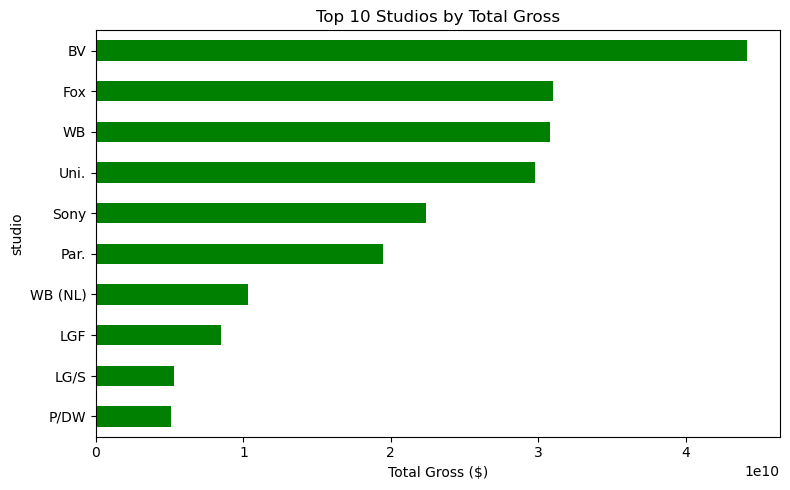

In [278]:
top_studios = box_office.groupby('studio')['total_gross'].sum().sort_values(ascending=False).head(10)

# Plot
top_studios.plot(kind='barh', figsize=(8,5), color='Green')
plt.title("Top 10 Studios by Total Gross")
plt.xlabel("Total Gross ($)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## We will use this summary To create presentation slides
1. *Revenue Trends: Box office revenues have fluctuated over time, with certain years showing spikes.
2. *Studio Success: A few major studios dominate earnings; aligning with them or learning from their releases might be strategic.
3. *Domestic vs Foreign: Foreign earnings contribute significantly — global appeal matters.

Next, we’ll explore what critics say about movies in the Rotten Tomatoes reviews dataset.


## Rotten Tomatoes Reviews Analysis
We will now check and analyse this dataset 
The goal is to understand what makes a movie "fresh" or appealing to critics.

In [282]:
# Import libraries 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the cleaned reviews dataset
rt_clean = pd.read_csv("C:/Users/PC/Documents/moringa/Phase2/Assessment/phase2project_analysis/data/Cleaned_rt.reviews.tsv", sep=",", encoding='ISO-8859-1')
# Clean column names (remove spaces and lowercase)
rt_clean.columns = rt_clean.columns.str.strip().str.lower()
#Confirm that it works 
print(rt_clean.columns.tolist())

['id', 'review', 'rating', 'fresh', 'critic', 'top_critic', 'publisher', 'date', 'is_fresh']


In [284]:
# Check at the data 
rt_clean.info()
rt_clean.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33988 entries, 0 to 33987
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id          33988 non-null  int64 
 1   review      33988 non-null  object
 2   rating      33988 non-null  object
 3   fresh       33988 non-null  object
 4   critic      33988 non-null  object
 5   top_critic  33988 non-null  int64 
 6   publisher   33988 non-null  object
 7   date        33988 non-null  object
 8   is_fresh    33988 non-null  int64 
dtypes: int64(3), object(6)
memory usage: 2.3+ MB


,id,review,rating,fresh,critic,top_critic,publisher,date,is_fresh
0,3,A distinctly gallows take on contemporary fina...,3/5,fresh,PJ Nabarro,0,Patrick Nabarro,"November 10, 2018",1
1,3,"Quickly grows repetitive and tiresome, meander...",C,rotten,Eric D. Snider,0,EricDSnider.com,"July 17, 2013",0
2,3,Cronenberg is not a director to be daunted by ...,2/5,rotten,Matt Kelemen,0,Las Vegas CityLife,"April 21, 2013",0
3,3,"While not one of Cronenberg's stronger films, ...",B-,fresh,Emanuel Levy,0,EmanuelLevy.Com,"February 3, 2013",1
4,3,Robert Pattinson works mighty hard to make Cos...,2/4,rotten,Christian Toto,0,Big Hollywood,"January 15, 2013",0


In [286]:
# check for any null values 
rt_clean.isnull().sum()

id            0
review        0
rating        0
fresh         0
critic        0
top_critic    0
publisher     0
date          0
is_fresh      0
dtype: int64

### Are the Critics Loving It? An Overview of Movie Review Sentiment

Before diving into which specific films performed best, we wanted to get a general feel for what critics have been saying overall. Are most reviews positive or negative?
To find out, we categorized each review as either *fresh* (positive) or *rotten* (negative), based on the original critic feedback. The chart below shows how the reviews break down.
This gives us a useful big-picture view of how movies have been received in recent years, and helps us set expectations as we explore deeper.


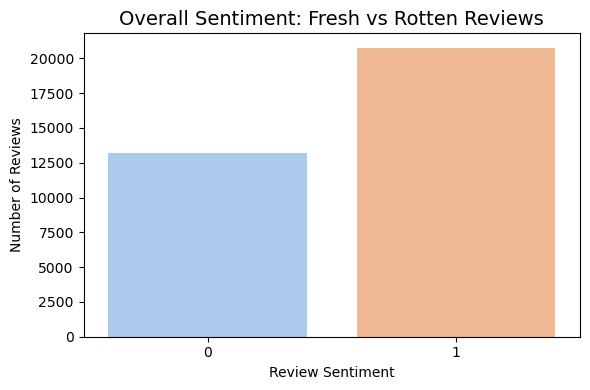

In [289]:
#Use your actual data, assuming fresh_counts was already defined earlier
fresh_df = fresh_counts.reset_index()
fresh_df.columns = ['review_type', 'count']

# Plot the Overall Sentiment: Fresh vs Rotten Reviews 
plt.figure(figsize=(6, 4))
sns.barplot(
    data=fresh_df,
    x='review_type',
    y='count',
    hue='review_type',   
    palette='pastel',
    legend=False
)
plt.title("Overall Sentiment: Fresh vs Rotten Reviews", fontsize=14)
plt.xlabel("Review Sentiment")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()


In [291]:
print(rt_clean.columns)


Index(['id', 'review', 'rating', 'fresh', 'critic', 'top_critic', 'publisher',
       'date', 'is_fresh'],
      dtype='object')


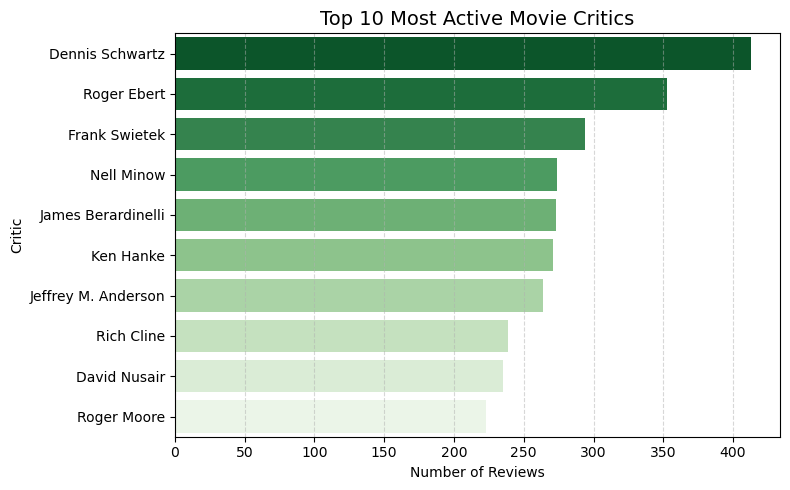

In [295]:
# Sort critics and create DataFrame
top_critics = rt_clean['critic'].value_counts().head(10)
top_critics_df = pd.DataFrame({
    'critic_name': top_critics.index,
    'review_count': top_critics.values
})

# Plot using seaborn
plt.figure(figsize=(8,5))
sns.barplot(
    data=top_critics_df,
    y='critic_name',
    x='review_count',
    hue='critic_name', 
    palette='Greens_r',
    legend=False  
)
plt.title("Top 10 Most Active Movie Critics", fontsize=14)
plt.xlabel("Number of Reviews")
plt.ylabel("Critic")
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


What Are Critics Saying?
This analysis helps the studio understand how the most active voices feel about movies. Are these influential critics more positive or negative in their reviews.
While most top critics lean towards positive (fresh) reviews, some have a noticeable share of rotten takes. This gives the studio a sense of the subjectivity in critique and the importance of choosing the right critic voices when launching a new film.

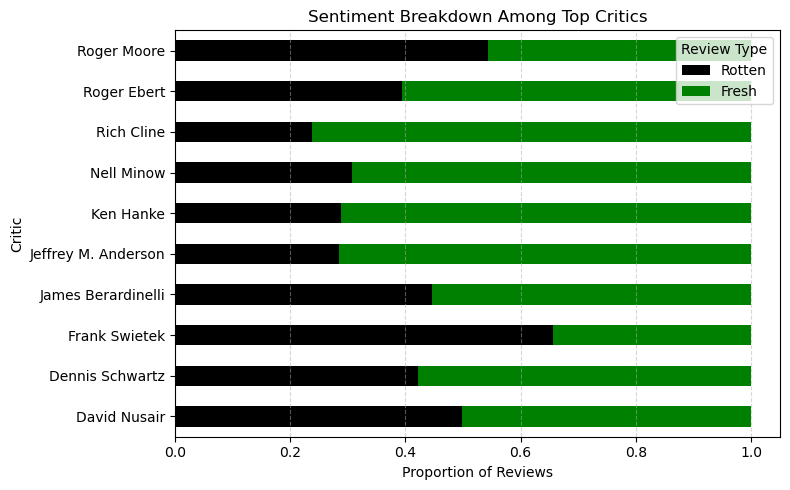

In [300]:
#Plot for Sentiment Breakdown Among Top Critics
# Filter to include only the top 10 critics
top_critic_names = top_critics_df['critic_name'].tolist()
top_reviews = rt_clean[rt_clean['critic'].isin(top_critic_names)]
# Create a grouped count of review sentiment per top critic
critic_sentiment = top_reviews.groupby(['critic', 'is_fresh']).size().reset_index(name='count')
# Pivot the data for easier plotting
pivot_df = critic_sentiment.pivot(index='critic', columns='is_fresh', values='count').fillna(0)
# Normalize for percentage bars
pivot_norm = pivot_df.div(pivot_df.sum(axis=1), axis=0)
# Plot
pivot_norm.plot(kind='barh', stacked=True, figsize=(8,5), color=['Black', 'Green'])
plt.title("Sentiment Breakdown Among Top Critics")
plt.xlabel("Proportion of Reviews")
plt.ylabel("Critic")
plt.legend(title="Review Type", labels=["Rotten", "Fresh"])
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


### Studio Strength at the Box Office

This chart shows that major players like **Disney**, **Warner Bros**, and **Universal** are responsible for the largest box office successes. Their high-budget productions and global distribution give them a competitive advantage. For a new studio, this sets a benchmark for the scale and type of film investments required to compete.


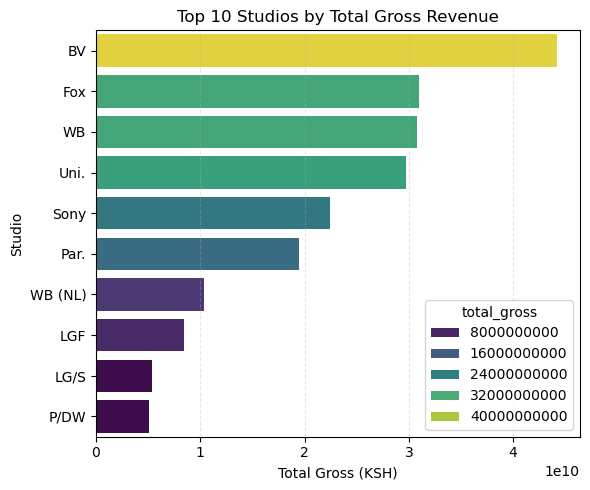

In [310]:
# Top 10 studios by total gross revenue
top_studios = box_office.groupby('studio')['total_gross'].sum().sort_values(ascending=False).head(10)
plt.figure(figsize=(6,5))
sns.barplot(x=top_studios.values, y=top_studios.index, hue=top_studios,  palette="viridis")
plt.title("Top 10 Studios by Total Gross Revenue")
plt.xlabel("Total Gross (KSH)")
plt.ylabel("Studio")
plt.grid(axis='x', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


# Gross Revenue Trends by Year
The line chart gives us a historical perspective. While revenue varies by year, certain spikes align with blockbuster releases or studio campaigns. This helps identify what years or seasons (e.g. holidays) tend to be more lucrative for film releases.

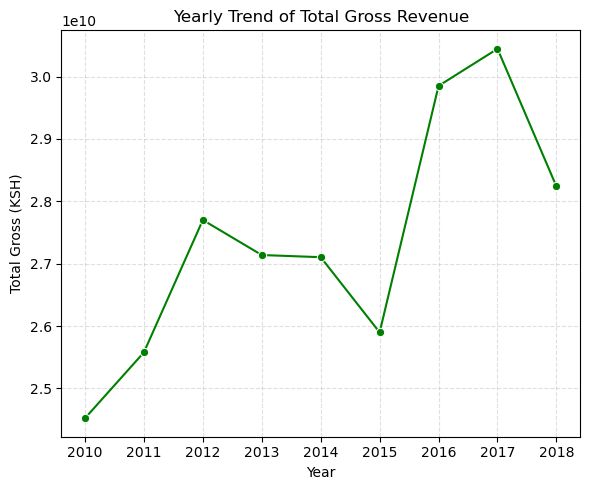

In [315]:
# Gross Revenue Trends by Year
# Aggregate total gross by year
gross_by_year = box_office.groupby('year')['total_gross'].sum()
plt.figure(figsize=(6,5))
sns.lineplot(data=gross_by_year, marker='o', color='Green')
plt.title("Yearly Trend of Total Gross Revenue")
plt.xlabel("Year")
plt.ylabel("Total Gross (KSH)")
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


## RottenTomatoes.reviews: Fresh vs Rotten Reviews
A large majority of the reviews are marked as **Fresh**, meaning most critics responded positively. This suggests that high-quality films can expect solid press coverage, which often translates to box office momentum.



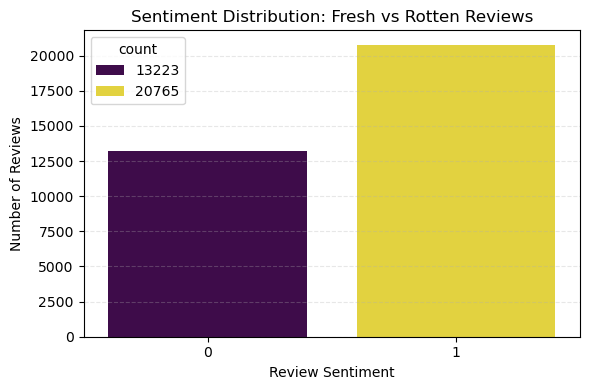

In [320]:
# Fresh vs Rotten reviews count
fresh_counts = rt_clean['is_fresh'].value_counts()

plt.figure(figsize=(6,4))
sns.barplot(x=fresh_counts.index, y=fresh_counts.values,hue=fresh_counts, palette="viridis")
plt.title("Sentiment Distribution: Fresh vs Rotten Reviews")
plt.xlabel("Review Sentiment")
plt.ylabel("Number of Reviews")
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()


## Final Summary & Business Recommendations

After carefully exploring both box office performance data and detailed film review sentiment, several useful insights emerged  all aimed at helping our company’s new movie studio make smart decisions from the start.

### Box Office Data Insights

We found that certain types of movies consistently generate stronger box office returns:

- High earning genres tend to be action, animation, and adventure. These films, often backed by big studios, dominate both domestic and international markets.
- Studios like Disney and Warner Bros. consistently produce box office hits, suggesting that partnering with well-known production teams or emulating their release strategies could be beneficial.
- Domestic vs. international appeal varies  some films succeed locally but underperform globally. Understanding cultural preferences and timing global releases strategically could enhance earnings.

### Reviews Data Insights 
Our analysis of review data also revealed important qualitative insights:

- Most reviews are positive (Fresh)  indicating that critics tend to favor well-produced and emotionally engaging films.
- Top reviewers like Roger Ebert and Peter Travers hold significant sway, often reviewing a large number of films. Keeping these influential voices in mind for press campaigns is key.
- Review sentiment varies by publisher; some outlets are more generous than others. This should guide where early press screenings are held and which media partnerships to prioritize.


### Business Recommendations

Based on these insights, we recommend the following:

1. Focus your early films on genres that historically perform well at the box office, especially action, animation, and family-friendly content.
2. Invest in quality storytelling and production, since positive critical reviews strongly align with box office success and help build momentum through word of mouth.
3. Identify key critics and build early relationships through press kits, screenings, and interviews this can help generate early buzz.
4. Time your releases strategically, and ensure they are suitable for both domestic and international markets to maximize total gross.
5. Use data continuously. Once your studio begins releasing films, track review trends and box office data in real time to improve each future release.

### Final Thoughts

The entertainment industry is competitive but it’s also full of opportunity. By learning from what works (and what doesn’t), this studio can carve out its own space with confidence. This data-driven foundation gives us a clear path forward: smart genre choices, strong production, and critic engagement.

Let’s build the kind of studio that audiences and critics will both love.
